<h1><b>Intelligent Resume Screening System</b></h1>

## **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## **Download NLTK data**

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
df = pd.read_csv("Resume.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (2484, 4)

Columns:
['ID', 'Resume_str', 'Resume_html', 'Category']


## **Explore the dataset**

In [ ]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [ ]:
df.isnull().sum()

,0
ID,0
Resume_str,0
Resume_html,0
Category,0


In [ ]:
print(df["Category"].value_counts())

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


## **Extract text from resumes**

In [ ]:
def extract_text(html):
    soup = BeautifulSoup(str(html), "html.parser")
    return soup.get_text(separator=" ")

df["Resume_Text"] = df["Resume_html"].apply(extract_text)

print(df["Resume_Text"].iloc[0][:1000])

                 HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR              Summary          Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.     Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.                Highlights                  Focused on customer satisfaction    Team management    Marketing savvy    Conflict resolution techniques          Training and development    Skilled multi-tasker    Client relations specialist                      Accomplishments            Missouri DOT Supervisor Training Certification    Certified by IHG in Customer Loyalty and Marketing by Segment     Hilton Worldwide General Manager Training Certification    Accomplished Trainer for cross server hospitality systems such as      Hilton OnQ    ,    Micros       Opera PMS      , Fidelio       OPERA       Reservation System (ORS)  ,     Holidex       

## **NLTK Preprocessing**

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [ ]:
df["Cleaned_Resume"] = df["Resume_Text"].apply(preprocess_text)

df[["Category", "Cleaned_Resume"]].head()

,Category,Cleaned_Resume
0,HR,hr administrator marketing associate hr admini...
1,HR,hr specialist u hr operation summary versatile...
2,HR,hr director summary year experience recruiting...
3,HR,hr specialist summary dedicated driven dynamic...
4,HR,hr manager skill highlight hr skill hr departm...


## **TF-IDF**

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

resume_vectors = vectorizer.fit_transform(
    df["Cleaned_Resume"]
)

print("TF-IDF Matrix Shape:", resume_vectors.shape)

TF-IDF Matrix Shape: (2484, 5000)


## **Enter Job Description**

Now create a job description.

In [ ]:
job_description = """
We are looking for a Python Developer with experience
in Machine Learning, Data Science, Pandas, NumPy,
Scikit-learn, SQL and Python programming.
The candidate should have good problem solving
and analytical skills.
"""

In [ ]:
cleaned_job = preprocess_text(job_description)

print(cleaned_job)

looking python developer experience machine learning data science panda numpy scikit learn sql python programming candidate good problem solving analytical skill


## **Convert Job Description into TF-IDF**

In [ ]:
job_vector = vectorizer.transform([cleaned_job])

## **Calculate Similarity**

In [ ]:
similarity_scores = cosine_similarity(
    job_vector,
    resume_vectors
)[0]

df["Relevance_Score"] = similarity_scores

df["Match_Percentage"] = (
    df["Relevance_Score"] * 100
).round(2)

## **Rank Candidates**

In [ ]:
ranked_resumes = df.sort_values(
    by="Match_Percentage",
    ascending=False
).reset_index(drop=True)

ranked_resumes["Rank"] = ranked_resumes.index + 1

In [ ]:
top_candidates = ranked_resumes[
    ["Rank", "Category", "Match_Percentage"]
].head(10)

top_candidates

,Rank,Category,Match_Percentage
0,1,CONSULTANT,20.92
1,2,ENGINEERING,19.95
2,3,ENGINEERING,19.80
3,4,AUTOMOBILE,18.79
4,5,AGRICULTURE,18.76
5,6,AUTOMOBILE,17.64
6,7,DIGITAL-MEDIA,17.20
7,8,INFORMATION-TECHNOLOGY,16.29
8,9,CONSULTANT,16.09
9,10,BANKING,15.76


## **Add Suitability**

In [ ]:
def suitability(score):

    if score >= 75:
        return "Highly Suitable"

    elif score >= 50:
        return "Suitable"

    elif score >= 30:
        return "Moderately Suitable"

    else:
        return "Low Match"

In [ ]:
ranked_resumes["Suitability"] = (
    ranked_resumes["Match_Percentage"]
    .apply(suitability)
)

In [ ]:
ranked_resumes[
    [
        "Rank",
        "Category",
        "Match_Percentage",
        "Suitability"
    ]
].head(10)

,Rank,Category,Match_Percentage,Suitability
0,1,CONSULTANT,20.92,Low Match
1,2,ENGINEERING,19.95,Low Match
2,3,ENGINEERING,19.80,Low Match
3,4,AUTOMOBILE,18.79,Low Match
4,5,AGRICULTURE,18.76,Low Match
5,6,AUTOMOBILE,17.64,Low Match
6,7,DIGITAL-MEDIA,17.20,Low Match
7,8,INFORMATION-TECHNOLOGY,16.29,Low Match
8,9,CONSULTANT,16.09,Low Match
9,10,BANKING,15.76,Low Match


## **Visualization**

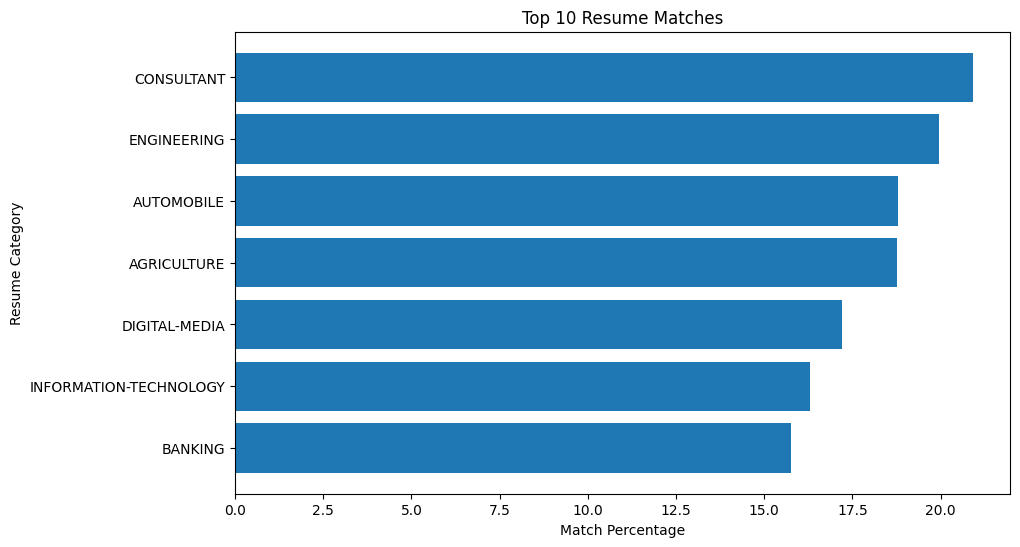

In [ ]:
top10 = ranked_resumes.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Category"],
    top10["Match_Percentage"]
)

plt.xlabel("Match Percentage")
plt.ylabel("Resume Category")
plt.title("Top 10 Resume Matches")

plt.gca().invert_yaxis()

plt.show()

## **Saves** **Results**

In [ ]:
ranked_resumes.to_csv(
    "Resume_Screening_Results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


## **DOWNLOAD IT**

In [ ]:
from google.colab import files

files.download("Resume_Screening_Results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>